# Bài tập thực hành chính quy: Xử lý ảnh và thị giác máy tính

Notebook này là học liệu hướng dẫn và khung làm bài cho hai chủ đề:

1. Hình thái học toán học.
2. Biến đổi hình học và chống răng cưa (anti-aliasing).

Phiên bản này yêu cầu sinh viên **tự viết nhiều thành phần nền tảng**, thay vì chỉ gọi các hàm trợ giúp có sẵn. Mục tiêu là buộc sinh viên hiểu bản chất của phép toán thay vì chỉ quan sát đầu ra.


# Thiết lập chung


In [27]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    cv2 = None

%matplotlib inline

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'gray'


In [28]:
def show_image(img, title='', cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_images(images, titles=None, cols=3, cmap='gray', figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# Ảnh kiểm thử


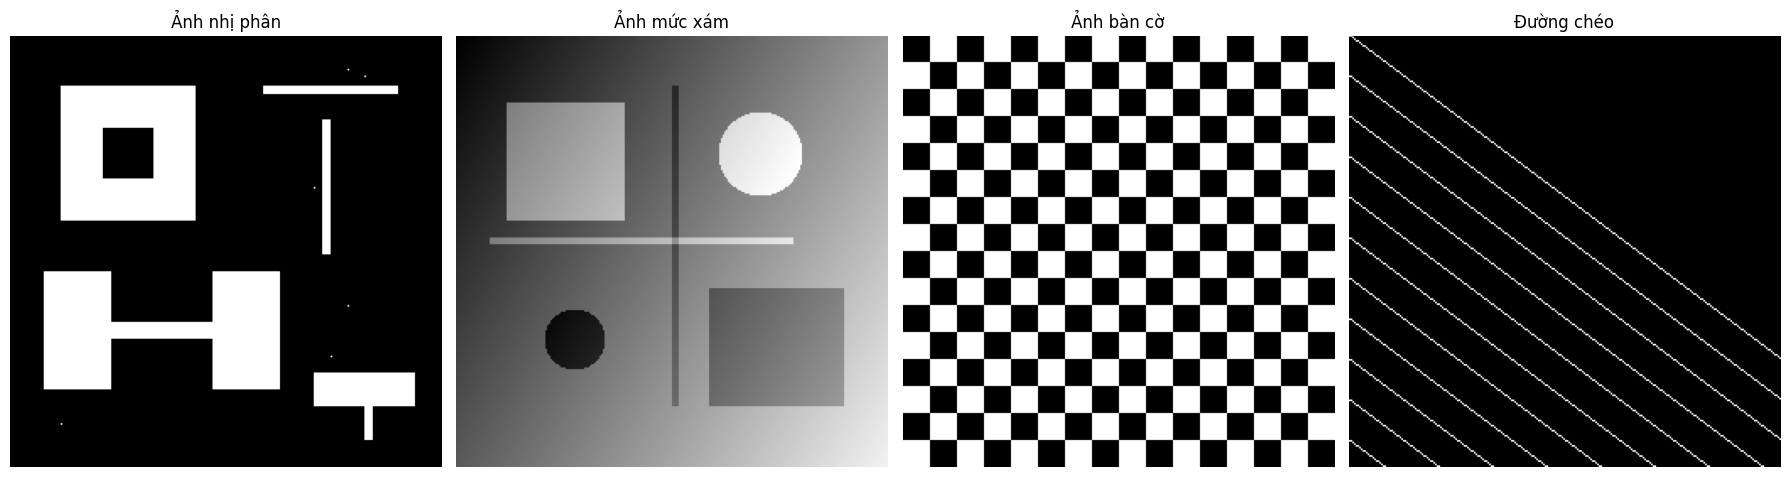

In [29]:
def make_binary_test_image(size=256):
    img = np.zeros((size, size), dtype=np.uint8)
    img[30:110, 30:110] = 255
    img[55:85, 55:85] = 0
    img[140:210, 20:60] = 255
    img[170:180, 60:120] = 255
    img[140:210, 120:160] = 255
    img[30:35, 150:230] = 255
    img[50:130, 185:190] = 255
    img[200:220, 180:240] = 255
    img[220:240, 210:215] = 255
    noise_points = [(20, 200), (24, 210), (90, 180), (160, 200), (190, 190), (230, 30)]
    for r, c in noise_points:
        img[r, c] = 255
    return img


def make_grayscale_test_image(size=256):
    y, x = np.mgrid[0:size, 0:size]
    base = 40 + 0.5 * x + 0.3 * y
    img = base.astype(np.float32)
    img[40:110, 30:100] += 80
    img[150:220, 150:230] -= 50
    rr = (x - 180) ** 2 + (y - 70) ** 2
    img[rr < 25**2] += 90
    img[(x - 70) ** 2 + (y - 180) ** 2 < 18**2] -= 70
    img[120:124, 20:200] += 60
    img[30:220, 128:132] -= 40
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)


def make_checkerboard(size=256, block=16):
    y, x = np.indices((size, size))
    board = ((x // block + y // block) % 2) * 255
    return board.astype(np.uint8)


def make_diagonal_lines(size=256):
    """Ảnh với nhiều đường chéo mảnh -- đặc biệt nhạy cảm với răng cưa."""
    img = np.zeros((size, size), dtype=np.uint8)
    for k in range(0, size, 24):
        for t in range(size):
            r = k + t * 3 // 4
            c = t
            if 0 <= r < size:
                img[r, c] = 255
    return img


binary_img = make_binary_test_image()
grayscale_img = make_grayscale_test_image()
checkerboard_img = make_checkerboard()
diagonal_img = make_diagonal_lines()

show_images(
    [binary_img, grayscale_img, checkerboard_img, diagonal_img],
    titles=['Ảnh nhị phân', 'Ảnh mức xám', 'Ảnh bàn cờ', 'Đường chéo'],
    cols=4,
    figsize=(18, 5)
)


# Bài tập 1: Hình thái học toán học

## Yêu cầu trọng tâm

Sinh viên phải tự viết:

- hàm tạo phần tử cấu trúc,
- hàm padding cho ảnh nhị phân,
- các phép erosion, dilation, opening, closing, gradient.

## Quy ước phần tử cấu trúc

Chỉ dùng ba họ:

- `rectangle`: gồm vuông, ngang, dọc,
- `cross`,
- `ellipse`.

Không dùng `diamond`.


## Việc sinh viên phải làm

1. Tự cài đặt hàm sinh phần tử cấu trúc theo kích thước bất kỳ hợp lệ.
2. Với `rectangle`, phải hỗ trợ cả trường hợp vuông, chữ nhật ngang, chữ nhật dọc.
3. Tự cài đặt padding cho ảnh nhị phân.
4. Tự cài đặt erosion, dilation, opening, closing, gradient.
5. Thử trên ảnh nhị phân kiểm thử và ảnh mẫu giảng viên cung cấp.


In [30]:
# TODO: Sinh viên tự viết hàm padding cho ảnh nhị phân

def pad_binary_image_manual(img, pad_h, pad_w, mode='constant'):
    # pad_h, pad_w: số pixel thêm mỗi phía (trên/dưới, trái/phải); mode='constant' → 0
    if mode != 'constant':
        raise ValueError("Chi ho tro mode='constant'")
    pad_h, pad_w = int(pad_h), int(pad_w)
    if pad_h < 0 or pad_w < 0:
        raise ValueError('pad_h, pad_w phai >= 0')
    h, w = img.shape[:2]
    out = np.zeros((h + 2 * pad_h, w + 2 * pad_w), dtype=img.dtype)
    out[pad_h:pad_h + h, pad_w:pad_w + w] = img
    return out


In [31]:
# TODO: Sinh viên tự viết hàm tạo phần tử cấu trúc

def make_structuring_element(shape, ksize):
    # shape: 'rectangle', 'cross', 'ellipse' — ksize: (height, width)
    h, w = int(ksize[0]), int(ksize[1])
    if h <= 0 or w <= 0:
        raise ValueError('ksize phai la (height, width) hop le, > 0')
    shape = shape.lower()
    if shape == 'diamond':
        raise ValueError('Khong dung diamond')
    se = np.zeros((h, w), dtype=np.uint8)
    if shape == 'rectangle':
        se[:, :] = 1
    elif shape == 'cross':
        cy, cx = h // 2, w // 2
        se[cy, :] = 1
        se[:, cx] = 1
    elif shape == 'ellipse':
        cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
        ry, rx = max(h / 2.0, 1e-6), max(w / 2.0, 1e-6)
        for i in range(h):
            for j in range(w):
                if ((i - cy) / ry) ** 2 + ((j - cx) / rx) ** 2 <= 1.0:
                    se[i, j] = 1
    else:
        raise ValueError("shape phai la 'rectangle', 'cross', hoac 'ellipse'")
    return se


In [32]:
# TODO: Sinh viên tự hoàn thiện các phép toán hình thái học

def erosion_binary(img, se):
    h, w = se.shape
    pad_h, pad_w = h // 2, w // 2
    
    padded = pad_binary_image_manual(img, pad_h, pad_w, mode='constant')
    out = np.zeros_like(img)
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            
            region = padded[i : i + h, j : j + w]
            
            if np.all(region[se == 1] == 255):
                out[i, j] = 255
    return out

def dilation_binary(img, se):
    h, w = se.shape
    pad_h, pad_w = h // 2, w // 2
    
    padded = pad_binary_image_manual(img, pad_h, pad_w, mode='constant')
    out = np.zeros_like(img)
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i : i + h, j : j + w]
            
            if np.any(region[se == 1] == 255):
                out[i, j] = 255
    return out

def opening_binary(img, se):
    eroded = erosion_binary(img, se)
    out = dilation_binary(eroded, se)
    return out


def closing_binary(img, se):
    dilated = dilation_binary(img, se)
    closed = erosion_binary(dilated, se)
    return closed


def morphological_gradient_binary(img, se):
    dilated = dilation_binary(img, se)
    eroded = erosion_binary(img, se)
    gradient = dilated.astype(np.float32) - eroded.astype(np.float32)
    return np.clip(gradient, 0, 255).astype(np.uint8)


THỬ NGHIỆM 1: OPENING - Loại bỏ nhiễu nhỏ


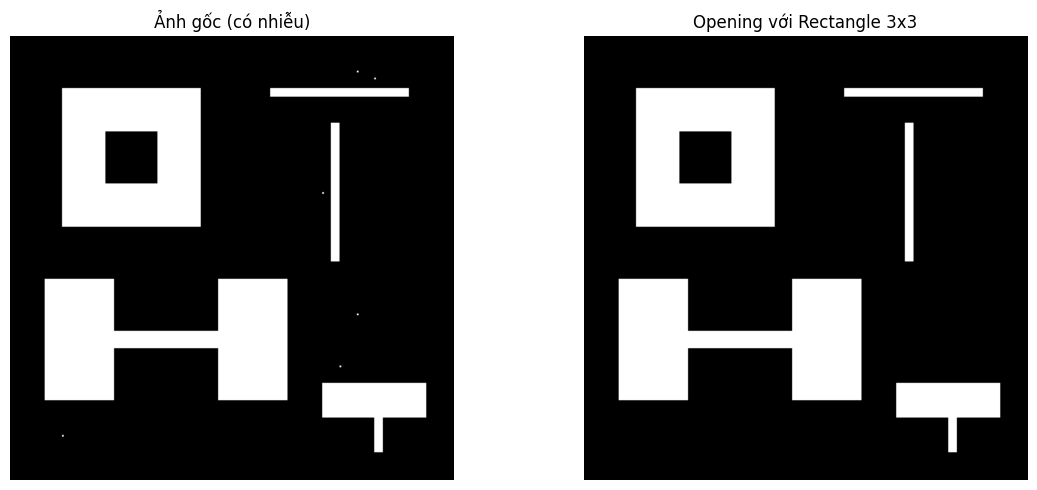

Nhận xét: Opening loại bỏ các điểm nhiễu nhỏ lẻ ở các góc

THỬ NGHIỆM 2: CLOSING - Lấp lỗ nhỏ bên trong vật


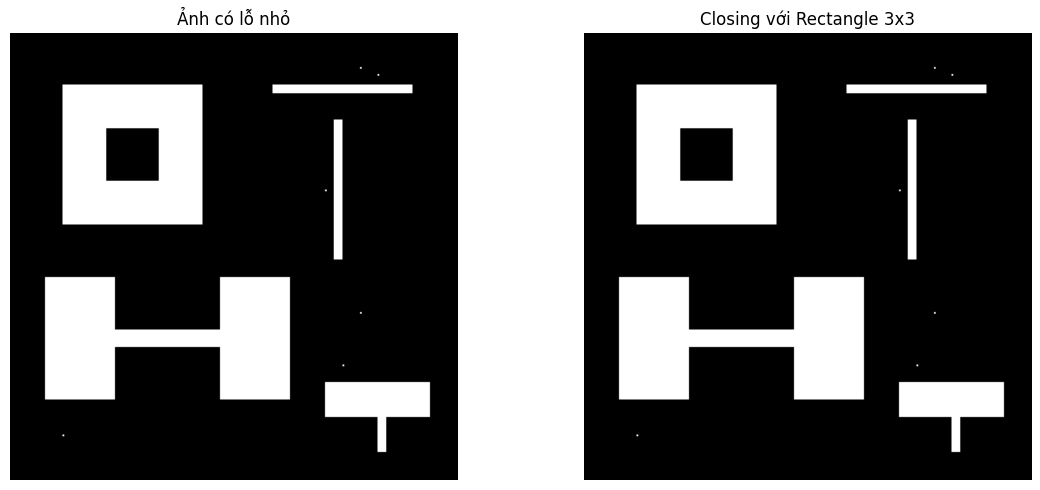

Nhận xét: Closing lấp đầy lỗ nhỏ bên trong vật mà không thay đổi lớn kích thước

THỬ NGHIỆM 3: MORPHOLOGICAL GRADIENT - Làm nổi ranh giới


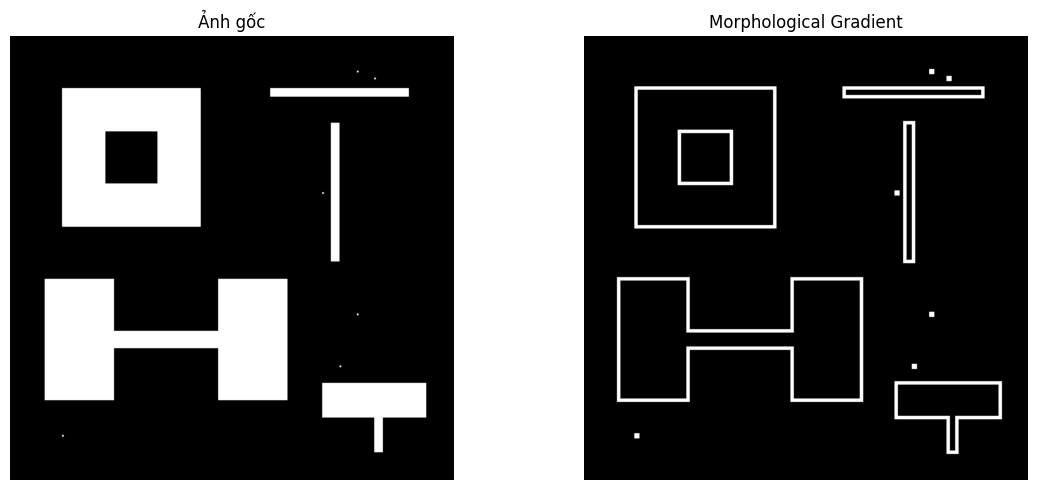

Nhận xét: Gradient chỉ giữ lại ranh giới/cạnh của vật, tạo hiệu ứng skeleton



In [33]:
# Ô thực hành gợi ý
# Sau khi hoàn thiện các hàm ở trên, sinh viên tự chạy các thử nghiệm ở đây.

# Ví dụ khung:
# se = make_structuring_element('rectangle', (3, 3))
# out = opening_binary(binary_img, se)
# show_images([binary_img, out], ['Đầu vào', 'Opening với rectangle 3x7'])

# Ví dụ 1: Phép Opening - loại bỏ nhiễu
print("=" * 60)
print("THỬ NGHIỆM 1: OPENING - Loại bỏ nhiễu nhỏ")
print("=" * 60)
se = make_structuring_element('rectangle', (3, 3))
out = opening_binary(binary_img, se)
show_images([binary_img, out], 
            ['Ảnh gốc (có nhiễu)', 'Opening với Rectangle 3x3'],
            cols=2, figsize=(12, 5))
print("Nhận xét: Opening loại bỏ các điểm nhiễu nhỏ lẻ ở các góc")
print()
# Ví dụ 2: Phép Closing - lấp lỗ nhỏ
print("=" * 60)
print("THỬ NGHIỆM 2: CLOSING - Lấp lỗ nhỏ bên trong vật")
print("=" * 60)
# Tạo ảnh có lỗ nhỏ bên trong
test_img_with_hole = binary_img.copy()
test_img_with_hole[65:75, 65:75] = 0  # Tạo lỗ nhỏ bên trong hình chữ nhật
closed = closing_binary(test_img_with_hole, se)
show_images([test_img_with_hole, closed],
            ['Ảnh có lỗ nhỏ', 'Closing với Rectangle 3x3'],
            cols=2, figsize=(12, 5))
print("Nhận xét: Closing lấp đầy lỗ nhỏ bên trong vật mà không thay đổi lớn kích thước")
print()
# Ví dụ 3: Phép Gradient - làm nổi ranh giới
print("=" * 60)
print("THỬ NGHIỆM 3: MORPHOLOGICAL GRADIENT - Làm nổi ranh giới")
print("=" * 60)
gradient = morphological_gradient_binary(binary_img, se)
show_images([binary_img, gradient],
            ['Ảnh gốc', 'Morphological Gradient'],
            cols=2, figsize=(12, 5))
print("Nhận xét: Gradient chỉ giữ lại ranh giới/cạnh của vật, tạo hiệu ứng skeleton")
print()

# Bài tập 2: Biến đổi hình học và Chống Răng Cưa

Bài tập này xây dựng toàn bộ pipeline biến đổi hình học có anti-aliasing.

## Phân biệt hai cơ chế cốt lõi

| Cơ chế | Kernel | Hàm dùng |
|---|---|---|
| **Tích chập** (`convolution`) | Cố định, không đổi theo vị trí | `convolve2d_manual` gọi **một lần** cho cả ảnh |
| **Tích vô hướng cục bộ** (`local dot product`) | Thay đổi theo $\delta_r, \delta_c$ của từng pixel | Tính **bên trong vòng lặp** của `warp_affine_manual` |

- **Nearest, Bilinear, SSAA** → kernel cố định hoặc không cần kernel → `convolve2d_manual` có thể dùng.
- **Bicubic, Lanczos** → kernel phụ thuộc vào phần lẻ $\delta$ của tọa độ nguồn → **không thể** gọi `convolve2d_manual` một lần toàn ảnh; phải tính cục bộ mỗi pixel.

## Việc sinh viên phải làm

1. Cài đặt ít nhất hai phép biến đổi affine (bắt buộc có quay và co giãn/shear).
2. Cài đặt `nearest_interpolate` và `bilinear_interpolate`.
3. **Tự viết** `convolve2d_manual` bằng vòng lặp (dùng cho SSAA và làm mượt sau warp).
4. Cài đặt `warp_affine_manual` dùng ánh xạ ngược.
5. Cài đặt `warp_affine_ssaa` dùng `convolve2d_manual` (tích chập cố định).
6. Cài đặt `bicubic_interpolate` và `lanczos_interpolate` (tích vô hướng cục bộ).
7. Tích hợp bicubic/Lanczos vào `warp_affine_manual` qua tham số `interpolation`.

## Ràng buộc

- Không dùng `cv2.warpAffine`, `scipy.ndimage.affine_transform`, `skimage.transform.warp`.
- Không dùng `scipy.signal.convolve2d`, `np.convolve` hay hàm tích chập có sẵn -- phải tự viết vòng lặp.
- Không chọn biến đổi quá tầm thường (quay 0°) làm ví dụ chính.


## Phần A -- Nội suy và tích chập nền tảng

### nearest_interpolate / bilinear_interpolate
**Cơ chế:** tích vô hướng cục bộ với cửa sổ cố định ($1\times1$ và $2\times2$).  
Kernel không phụ thuộc vào $\delta$ theo cách phức tạp -- bilinear dùng
$\mathbf{w}_r = [1-\delta_r, \delta_r]$ và $\mathbf{w}_c = [1-\delta_c, \delta_c]$,
tích ngoài cho ma trận $2\times2$.

### convolve2d_manual
**Cơ chế:** tích chập thực sự -- kernel **cố định**, trượt qua toàn ảnh.  
Dùng cho SSAA (kernel hộp $L\times L$) và làm mượt sau warp (kernel Gaussian).  
**Không phù hợp** cho Bicubic/Lanczos vì kernel của chúng thay đổi mỗi pixel.




In [34]:
def translation_matrix(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ], dtype=np.float32)


def scaling_matrix(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ], dtype=np.float32)


def rotation_matrix(deg):
    rad = np.deg2rad(deg)
    c, s = np.cos(rad), np.sin(rad)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ], dtype=np.float32)


def shear_matrix(shx=0.0, shy=0.0):
    return np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ], dtype=np.float32)


In [35]:
# TODO: Sinh viên tự hoàn thiện nội suy

def nearest_interpolate(img, x, y):
    """
    Nội suy nearest-neighbor tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng 1x1 -- chọn pixel nguyên gần nhất.
    Không phụ thuộc vào delta; không cần xây kernel.

    Trả về: float, giá trị tại pixel gần nhất.
    """
    h, w = img.shape[:2]

    xi = int(round(x))
    yi = int(round(y))

    if xi < 0 or xi >= w or yi < 0 or yi >= h:
        return 0.0

    return float(img[yi, xi])


def bilinear_interpolate(img, x, y):
    """
    Nội suy bilinear tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ 2x2.
    - delta_c = x - floor(x),  delta_r = y - floor(y)
    - w_c = [1-delta_c, delta_c]  (vector hàng)
    - w_r = [1-delta_r, delta_r]  (vector cột)
    - Patch P = I[floor(y):floor(y)+2, floor(x):floor(x)+2]
    - Kết quả = w_r @ P @ w_c  (tích vô hướng, KHÔNG phải tích chập)

    Trả về: float, clamp về [0, 255].
    """
    h, w = img.shape[:2]

    x0 = int(np.floor(x))
    y0 = int(np.floor(y))

    x1 = x0 + 1
    y1 = y0 + 1

    if x0 < 0 or y0 < 0 or x1 >= w or y1 >= h:
        return 0.0

    dx = x - x0
    dy = y - y0

    Q00 = float(img[y0, x0])
    Q01 = float(img[y0, x1])
    Q10 = float(img[y1, x0])
    Q11 = float(img[y1, x1])

    top = (1 - dx) * Q00 + dx * Q01
    bottom = (1 - dx) * Q10 + dx * Q11

    return float((1 - dy) * top + dy * bottom)

In [36]:
# TODO: Sinh viên tự viết tích chập 2D bằng vòng lặp
# Không được dùng bất kỳ hàm tích chập có sẵn nào.

def convolve2d_manual(img, kernel, pad_mode='constant', pad_value=0):
    """
    Tích chập 2D thủ công -- kernel CỐ ĐỊNH, trượt qua toàn ảnh.

    Dùng cho:
      - SSAA: kernel = np.ones((L,L))/L**2  (box filter)
      - Làm mượt sau warp: kernel = gaussian_kernel(n)
    KHÔNG dùng cho Bicubic/Lanczos (kernel của chúng thay đổi theo delta).

    Tham số
    -------
    img       : np.ndarray (H, W), kiểu float
    kernel    : np.ndarray (kH, kW)  -- cố định, không phụ thuộc vào vị trí
    pad_mode  : 'constant' -- điền pad_value ngoài biên
    pad_value : giá trị điền khi pad_mode='constant'

    Trả về
    ------
    out : np.ndarray (H, W), cùng kiểu với img

    Gợi ý các bước
    --------------
    1. Lật kernel 180° (flip cả hàng lẫn cột) -- đây là điểm khác biệt
       giữa convolution và cross-correlation.
    2. Pad ảnh đầu vào đủ để giữ nguyên kích thước đầu ra.
    3. Duyệt từng pixel (r, c), tính tổng trọng số cửa sổ kernel.
    """
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    kernel_flipped = np.flipud(np.fliplr(kernel))

    if pad_mode == 'constant':
        padded = np.pad(
            img,
            ((pad_h, pad_h), (pad_w, pad_w)),
            mode='constant',
            constant_values=pad_value
        )
    else:
        padded = np.pad(
            img,
            ((pad_h, pad_h), (pad_w, pad_w)),
            mode=pad_mode
        )

    h, w = img.shape
    out = np.zeros((h, w), dtype=np.float32)

    for r in range(h):
        for c in range(w):
            patch = padded[r:r + kh, c:c + kw]
            out[r, c] = np.sum(patch * kernel_flipped)

    return out

In [37]:
# TODO: Sinh viên tự hoàn thiện warp affine bằng ánh xạ ngược

def warp_affine_manual(img, matrix, out_shape, interpolation='nearest', fill_value=0):
    """
    Biến đổi affine dùng ánh xạ ngược.

    Pipeline cho mỗi pixel đích (r', c'):
      [x, y, 1]^T = matrix^{-1} @ [c', r', 1]^T
      if (x, y) ngoài biên: gán fill_value
      else: gọi hàm nội suy phù hợp

    Phân biệt cơ chế theo interpolation:
      'nearest'  -> nearest_interpolate(img, x, y)
                    [tích vô hướng 1x1, không cần delta]
      'bilinear' -> bilinear_interpolate(img, x, y)
                    [tích vô hướng 2x2, w = f(delta)]
      'bicubic'  -> bicubic_interpolate(img, x, y)
                    [tích vô hướng 4x4, kernel = R(delta-i) -- thay đổi mỗi pixel]
      'lanczos'  -> lanczos_interpolate(img, x, y)
                    [tích vô hướng (2a)x(2a), kernel = L(delta-i) -- thay đổi mỗi pixel]

    Lưu ý: SSAA dùng hàm riêng warp_affine_ssaa, không qua đây.

    interpolation : 'nearest' | 'bilinear' | 'bicubic' | 'lanczos'
    """
    
    out_h, out_w = out_shape
    h, w = img.shape[:2]

    output = np.full((out_h, out_w), fill_value, dtype=np.float32)

    if matrix.shape[0] == 2:
        matrix_3x3 = np.vstack([matrix, [0, 0, 1]])
    else:
        matrix_3x3 = matrix

    matrix_inv = np.linalg.inv(matrix_3x3)

    for r in range(out_h):
        for c in range(out_w):
            src = matrix_inv @ np.array([c, r, 1], dtype=np.float32)

            x = src[0]
            y = src[1]

            if x < 0 or x >= w or y < 0 or y >= h:
                output[r, c] = fill_value
            else:
                if interpolation == 'nearest':
                    output[r, c] = nearest_interpolate(img, x, y)

                elif interpolation == 'bilinear':
                    output[r, c] = bilinear_interpolate(img, x, y)

                elif interpolation == 'bicubic':
                    output[r, c] = bicubic_interpolate(img, x, y)

                elif interpolation == 'lanczos':
                    output[r, c] = lanczos_interpolate(img, x, y)

                else:
                    output[r, c] = fill_value

    return output

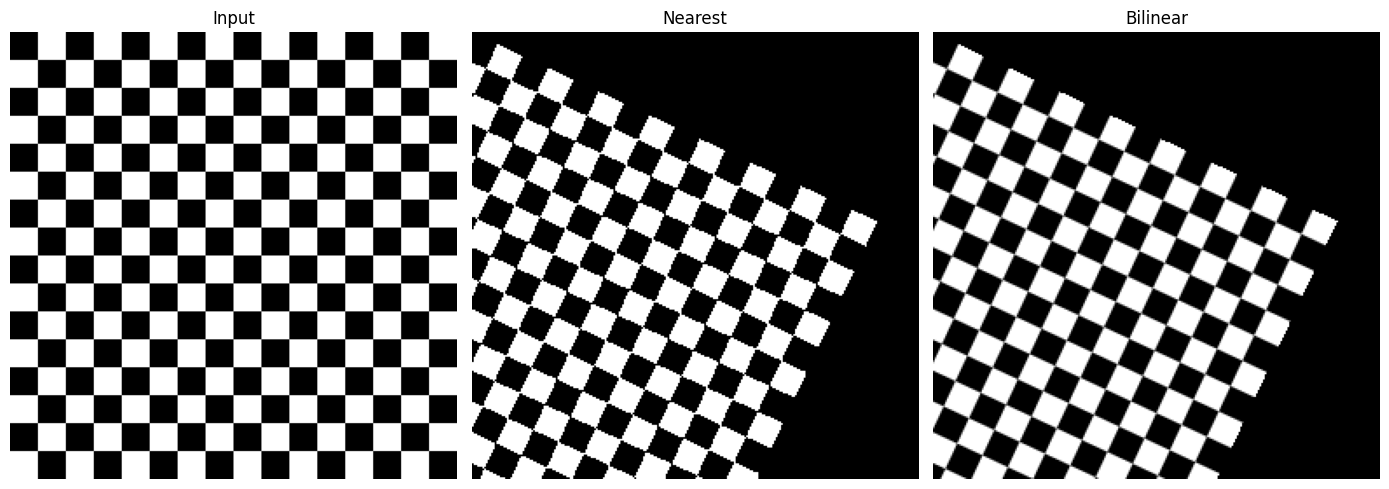

In [38]:
# Ô kiểm tra nhanh Phần A
# Ví dụ khung:
# M = rotation_matrix(25)
# out_nn = warp_affine_manual(checkerboard_img.astype(np.float32), M, checkerboard_img.shape, interpolation='nearest')
# out_bl = warp_affine_manual(checkerboard_img.astype(np.float32), M, checkerboard_img.shape, interpolation='bilinear')
# show_images([checkerboard_img, out_nn, out_bl], ['Đầu vào', 'Nearest', 'Bilinear'])

def rotation_matrix(angle_degrees):
    theta = np.radians(angle_degrees)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    return np.array([
        [cos_t, -sin_t, 0],
        [sin_t,  cos_t, 0]
    ], dtype=np.float32)

M = rotation_matrix(25)

out_nn = warp_affine_manual(
    checkerboard_img.astype(np.float32),
    M,
    checkerboard_img.shape,
    interpolation='nearest'
)

out_bl = warp_affine_manual(
    checkerboard_img.astype(np.float32),
    M,
    checkerboard_img.shape,
    interpolation='bilinear'
)

show_images(
    [checkerboard_img, out_nn, out_bl],
    ['Input', 'Nearest', 'Bilinear']
)


## Phần B -- Anti-aliasing qua nội suy nâng cao

Khi xoay hoặc phóng to ảnh, các đường chéo và cạnh cong trông gồ ghề
(răng cưa / jaggies). Nguyên nhân: tọa độ nguồn $(y, x)$ sau ánh xạ ngược
không trùng với lưới pixel -- phần lẻ $\delta$ khác nhau mỗi pixel đích.

### Hai cách chống răng cưa

**Cách 1 -- Tích chập cố định (SSAA):**  
Warp bằng nearest, rồi gọi `convolve2d_manual` với kernel hộp.  
Kernel không thay đổi → có thể dùng `convolve2d_manual` một lần.

**Cách 2 -- Tích vô hướng cục bộ với kernel thay đổi (Bicubic, Lanczos):**  
Bên trong vòng lặp của `warp_affine_manual`, mỗi pixel đích tính
$(\delta_r, \delta_c)$, xây weight vector $w_r, w_c$, rồi thực hiện
tích vô hướng với patch $4\times4$ hoặc $(2a)\times(2a)$.  
Kernel thay đổi mỗi pixel → **không thể** gọi `convolve2d_manual` toàn ảnh.


### Kỹ thuật 1: Supersampling Anti-Aliasing (SSAA) -- tích chập cố định

**Ý tưởng:** Lấy $L^2$ mẫu đều nhau trong diện tích pixel đích, mỗi mẫu
ánh xạ ngược về ảnh nguồn và nội suy bilinear, rồi trung bình.

$$C(r', c') = \frac{1}{L^2}\sum_{m=0}^{L-1}\sum_{n=0}^{L-1}
f\!\left(r'+\frac{m+0.5}{L},\;c'+\frac{n+0.5}{L}\right)$$

**Liên hệ với tích chập:** SSAA tương đương áp bộ lọc hộp $L\times L$
lên ảnh đã warp nearest. Kernel hộp **không phụ thuộc** vào $\delta$ --
nó như nhau tại mọi pixel:
$$K_{\text{box}}^{(L)} = \frac{1}{L^2}\mathbf{1}_{L\times L}$$

Vì vậy `warp_affine_ssaa` có thể được cài đặt theo một trong hai cách:
- **Cách A (khuyến khích):** warp nearest → `convolve2d_manual(warped, K_box)`.
- **Cách B:** vòng lặp $L^2$ mẫu mỗi pixel (theo công thức trên).

Cả hai cho cùng kết quả; Cách A tái sử dụng hàm đã viết.


In [39]:
# TODO: Sinh viên tự cài đặt SSAA

def warp_affine_ssaa(img, matrix, out_shape, L=2, fill_value=0):
    """
    Biến đổi affine với Supersampling Anti-Aliasing.

    Với mỗi pixel đích (r', c'), lấy L*L mẫu con đều nhau trong
    diện tích pixel, ánh xạ ngược từng mẫu con về ảnh nguồn,
    nội suy bilinear, rồi lấy trung bình.

    Gợi ý: offset mẫu con thứ (m, n) tại pixel (r', c') là
        (r' + (m + 0.5) / L,  c' + (n + 0.5) / L)
    trước khi ánh xạ ngược qua matrix^{-1}.

    L : int -- hệ số supersampling (L=2 => 4 mẫu/pixel, L=4 => 16 mẫu/pixel)
    """

    out_h, out_w = out_shape
    h, w = img.shape[:2]

    output = np.full((out_h, out_w), fill_value, dtype=np.float32)

    if matrix.shape[0] == 2:
        matrix_3x3 = np.vstack([matrix, [0, 0, 1]])
    else:
        matrix_3x3 = matrix

    matrix_inv = np.linalg.inv(matrix_3x3)

    for r in range(out_h):
        for c in range(out_w):

            total = 0.0

            for m in range(L):
                for n in range(L):
                    ry = r + (m + 0.5) / L
                    cx = c + (n + 0.5) / L

                    src = matrix_inv @ np.array([cx, ry, 1], dtype=np.float32)
                    x = src[0]
                    y = src[1]

                    if x < 0 or x >= w or y < 0 or y >= h:
                        total += fill_value
                    else:
                        total += bilinear_interpolate(img, x, y)

            output[r, c] = total / (L * L)

    return output

### Kỹ thuật 2: Bicubic -- tích vô hướng cục bộ $4\times4$

**Ý tưởng:** Dùng cửa sổ $4\times4$ pixel lân cận và hàm trọng số
cubic $R(d)$ (Keys) thay vì trung bình đều.

**Hàm trọng số 1D** ($a = -0.5$):
$$R(d) = \begin{cases}
(a+2)|d|^3 - (a+3)|d|^2 + 1 & |d| \leq 1 \\
a|d|^3 - 5a|d|^2 + 8a|d| - 4a & 1 < |d| < 2 \\
0 & \text{còn lại}
\end{cases}$$

**Tại sao không dùng `convolve2d_manual`?**  
Tại mỗi pixel đích, $\delta_r$ và $\delta_c$ khác nhau.  
Weight vector $\mathbf{w}_r = [R(\delta_r+1),\,R(\delta_r),\,R(\delta_r-1),\,R(\delta_r-2)]$
thay đổi theo $\delta_r$ -- kernel không cố định.  
Phải tính bên trong vòng lặp của `warp_affine_manual`.

**Công thức tích vô hướng cục bộ:**
$$P(y,x) = \mathbf{w}_r^T \cdot I_{\text{patch}} \cdot \mathbf{w}_c$$
trong đó $I_{\text{patch}}$ là ma trận $4\times4$ pixel lân cận.  
Không cần lật kernel (đây là tích vô hướng, không phải tích chập).


In [40]:
# TODO: Sinh viên tự cài đặt Bicubic

def cubic_kernel(d, a=-0.5):
    """
    Hàm trọng số bicubic 1D tại khoảng cách d -- Keys cubic.

    Trả về R(d) theo công thức piecewise.
    Kiểm tra: R(0)=1, R(1)=0, R(1.5)=-0.0625 với a=-0.5.
    """
    d = abs(d)

    if d <= 1:
        return (a + 2) * (d ** 3) - (a + 3) * (d ** 2) + 1

    elif d < 2:
        return a * (d ** 3) - 5 * a * (d ** 2) + 8 * a * d - 4 * a

    else:
        return 0.0


def bicubic_interpolate(img, x, y, a=-0.5):
    """
    Nội suy bicubic tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ 4x4 -- KHÔNG phải tích chập.
    - delta_r = y - floor(y),  delta_c = x - floor(x)
    - w_r[i] = cubic_kernel(delta_r - i)  cho i in {-1, 0, 1, 2}
    - w_c[j] = cubic_kernel(delta_c - j)  cho j in {-1, 0, 1, 2}
    - Patch P = I[floor(y)-1 : floor(y)+3, floor(x)-1 : floor(x)+3]
    - Kết quả = w_r @ P @ w_c  (tích vô hướng ma trận)

    Không cần lật kernel (khác với convolve2d_manual).
    Clamp kết quả về [0, 255].
    """
    h, w = img.shape[:2]

    x0 = int(np.floor(x))
    y0 = int(np.floor(y))

    delta_r = y - y0
    delta_c = x - x0

    result = 0.0
    total_weight = 0.0

    for i in range(-1, 3):
        for j in range(-1, 3):

            yy = y0 + i
            xx = x0 + j

            # kiểm tra biên
            if 0 <= yy < h and 0 <= xx < w:

                wr = cubic_kernel(delta_r - i, a)
                wc = cubic_kernel(delta_c - j, a)

                weight = wr * wc

                result += img[yy, xx] * weight

                total_weight += weight

    # chuẩn hoá
    if total_weight != 0:
        result /= total_weight

    return np.clip(result, 0, 255)


### Kỹ thuật 3: Lanczos -- tích vô hướng cục bộ $(2a)\times(2a)$

**Ý tưởng:** Dùng hàm sinc cửa sổ hoá -- xấp xỉ bộ lọc thông thấp lý tưởng.

**Hàm trọng số 1D** ($a = 2$ hoặc $3$):
$$L(x) = \begin{cases}
1 & x = 0 \\
\operatorname{sinc}(x)\cdot\operatorname{sinc}(x/a) & 0 < |x| < a \\
0 & |x| \geq a
\end{cases}$$
với $\operatorname{sinc}(x) = \sin(\pi x)/(\pi x)$.  
Gợi ý: `np.sinc(x)` trong NumPy đã là sinc chuẩn hoá (đã nhân $\pi$).

**Tại sao không dùng `convolve2d_manual`?**  
Giống bicubic: $\mathbf{w}_r[i] = L(\delta_r - i)$ thay đổi theo $\delta_r$
của từng pixel -- kernel không cố định.

**Công thức tích vô hướng cục bộ có chuẩn hoá:**
$$P(y,x) = \frac{\sum_i\sum_j I[\lfloor y\rfloor+i,\,\lfloor x\rfloor+j]\cdot w_r[i]\cdot w_c[j]}{\sum_i\sum_j w_r[i]\cdot w_c[j]}$$

Chuẩn hoá bắt buộc gần biên ảnh (một số pixel nằm ngoài biên bị bỏ qua,
tổng trọng số nhỏ hơn 1 nếu không chuẩn hoá).


In [41]:
# TODO: Sinh viên tự cài đặt Lanczos

def lanczos_kernel(x, a=3):
    """
    Hàm trọng số Lanczos 1D tại khoảng cách x.

    Trả về L(x) = sinc(x) * sinc(x/a) nếu |x| < a, else 0.
    Gợi ý: np.sinc(x) = sin(pi*x)/(pi*x), đã chuẩn hoá.
    Kiểm tra: L(0)=1, L(1)=0, L(0.5) > 0.
    """
    x = abs(x)

    if x < a:
        return np.sinc(x) * np.sinc(x / a)

    else:
        return 0.0


def lanczos_interpolate(img, x, y, a=3):
    """
    Nội suy Lanczos tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ (2a)x(2a) CÓ chuẩn hoá -- KHÔNG phải tích chập.
    - delta_r = y - floor(y),  delta_c = x - floor(x)
    - i in {-a+1, ..., a}: w_r[i] = lanczos_kernel(delta_r - i, a)
    - j in {-a+1, ..., a}: w_c[j] = lanczos_kernel(delta_c - j, a)
    - Tổng = sum_i sum_j I[floor(y)+i, floor(x)+j] * w_r[i] * w_c[j]
    - Chia cho sum_i sum_j w_r[i] * w_c[j]  (chuẩn hoá -- quan trọng gần biên)

    Không cần lật kernel.
    Clamp kết quả về [0, 255].
    """
    h, w = img.shape[:2]

    x0 = int(np.floor(x))
    y0 = int(np.floor(y))

    delta_r = y - y0
    delta_c = x - x0

    result = 0.0
    total_weight = 0.0

    for i in range(-a + 1, a + 1):
        for j in range(-a + 1, a + 1):

            yy = y0 + i
            xx = x0 + j

            # kiểm tra biên
            if 0 <= yy < h and 0 <= xx < w:

                wr = lanczos_kernel(delta_r - i, a)
                wc = lanczos_kernel(delta_c - j, a)

                weight = wr * wc

                result += img[yy, xx] * weight

                total_weight += weight

    # chuẩn hoá
    if total_weight != 0:
        result /= total_weight

    return np.clip(result, 0, 255)

### Tích hợp vào warp_affine_manual

Sau khi cài đặt `bicubic_interpolate` và `lanczos_interpolate`,
mở rộng `warp_affine_manual` để tham số `interpolation` chấp nhận
`'bicubic'` và `'lanczos'`.

Sơ đồ dispatch bên trong `warp_affine_manual`:
```
if interpolation == 'nearest':
    val = nearest_interpolate(img, x, y)     # tích vô hướng 1x1
elif interpolation == 'bilinear':
    val = bilinear_interpolate(img, x, y)    # tích vô hướng 2x2
elif interpolation == 'bicubic':
    val = bicubic_interpolate(img, x, y)     # tích vô hướng 4x4, kernel thay đổi
elif interpolation == 'lanczos':
    val = lanczos_interpolate(img, x, y)     # tích vô hướng (2a)^2, kernel thay đổi
```

`warp_affine_ssaa` dùng `convolve2d_manual` riêng -- không đi qua đây.


### So sánh và nhận xét

Chạy **cùng một phép quay** (ví dụ 25°) trên ảnh bàn cờ và ảnh đường chéo
với tất cả các kỹ thuật. Sau đó trả lời các câu hỏi sau trong một ô Markdown:

1. **Răng cưa:** Kỹ thuật nào cho đường chéo mượt nhất? Kỹ thuật nào tệ nhất?
2. **Độ mờ:** Bilinear và bicubic có làm mờ cạnh sắc không? Lanczos có hiện
   tượng "halo" (ringing) gần cạnh không?
3. **Chi phí tính toán:** Ước lượng số phép nhân cần để tính một pixel đích
   cho mỗi kỹ thuật (nearest, bilinear, bicubic, SSAA với $L=2$, Lanczos $a=3$).
4. **Trường hợp sử dụng:** Kỹ thuật nào phù hợp cho ảnh y tế (không được
   làm mờ biên quan trọng)? Kỹ thuật nào phù hợp cho ảnh màu tự nhiên?


In [42]:
# Ô thực hành so sánh anti-aliasing
# Sau khi hoàn thiện tất cả các hàm, chạy so sánh ở đây.

# Ví dụ khung:
# M = rotation_matrix(25)
# H, W = checkerboard_img.shape
# img_f = checkerboard_img.astype(np.float32)
#
# out_nn  = warp_affine_manual(img_f, M, (H, W), interpolation='nearest')
# out_bl  = warp_affine_manual(img_f, M, (H, W), interpolation='bilinear')
# out_bc  = warp_affine_manual(img_f, M, (H, W), interpolation='bicubic')
# out_lz  = warp_affine_manual(img_f, M, (H, W), interpolation='lanczos')
# out_ss  = warp_affine_ssaa(img_f, M, (H, W), L=2)
#
# show_images(
#     [checkerboard_img, out_nn, out_bl, out_bc, out_lz, out_ss],
#     titles=['Gốc', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos', 'SSAA L=2'],
#     cols=3, figsize=(15, 10)
# )

M = rotation_matrix(25)
H, W = checkerboard_img.shape
img_f = checkerboard_img.astype(np.float32)

out_nn  = warp_affine_manual(img_f, M, (H, W), interpolation='nearest')
out_bl  = warp_affine_manual(img_f, M, (H, W), interpolation='bilinear')
out_bc  = warp_affine_manual(img_f, M, (H, W), interpolation='bicubic')
out_lz  = warp_affine_manual(img_f, M, (H, W), interpolation='lanczos') 

out_ss  = warp_affine_ssaa(img_f, M, (H, W), L=2)

show_images(
     [checkerboard_img, out_nn, out_bl, out_bc, out_lz, out_ss],
     titles=['Gốc', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos', 'SSAA L=2'],
     cols=3, figsize=(15, 10)
)

KeyboardInterrupt: 

*(Sinh viên viết nhận xét so sánh ở đây)*
So sánh các phương pháp nội suy và chống răng cưa

1. Răng cưa (Aliasing)
- Kỹ thuật cho đường chéo mượt nhất là Lanczos và SSAA.
- Hai phương pháp này giảm hiện tượng răng cưa rất hiệu quả, đặc biệt ở các cạnh chéo của ảnh bàn cờ.
- Kỹ thuật tệ nhất là Nearest Neighbor vì chỉ lấy pixel gần nhất nên tạo ra các cạnh bị bậc thang rõ rệt.
- Bilinear cải thiện đáng kể so với Nearest nhưng vẫn còn hơi răng cưa.
- Bicubic cho kết quả mượt hơn Bilinear nhờ sử dụng nhiều pixel lân cận hơn.
2. Độ mờ và hiện tượng ringing
- Bilinear làm mờ cạnh khá rõ do thực hiện nội suy tuyến tính giữa các pixel.
- Bicubic cũng làm mờ nhẹ nhưng giữ chi tiết tốt hơn Bilinear.
- Lanczos giữ cạnh sắc nét tốt nhất, tuy nhiên có thể xuất hiện hiện tượng halo/ringing gần các cạnh tương phản mạnh (ví dụ cạnh đen–trắng của bàn cờ).
- Điều này xảy ra do kernel sinc dao động quanh biên.
3. Chi phí tính toán

Ước lượng số phép nhân để tính một pixel đích:

| Kỹ thuật      | Số mẫu sử dụng              | Ước lượng phép nhân |
| ------------- | --------------------------- | ------------------- |
| Nearest       | 1 pixel                     | ≈ 0–1               |
| Bilinear      | 4 pixel                     | ≈ 4                 |
| Bicubic       | 16 pixel                    | ≈ 16                |
| SSAA (L=2)    | 4 mẫu supersample + nội suy | ≈ 16–64             |
| Lanczos (a=3) | 6×6 = 36 pixel              | ≈ 36                |

Nearest nhanh nhất.
Lanczos và SSAA tốn chi phí tính toán cao nhất.

4. Trường hợp sử dụng
- Với ảnh y tế, cần giữ biên rõ và hạn chế làm mờ các chi tiết quan trọng, nên Lanczos hoặc Bicubic phù hợp hơn.
- Với ảnh màu tự nhiên (ảnh phong cảnh, chân dung), Bilinear hoặc Bicubic thường phù hợp vì cho ảnh mượt và tự nhiên.
- Nearest Neighbor phù hợp cho pixel art hoặc các ứng dụng yêu cầu tốc độ cao.
- SSAA phù hợp cho đồ họa và rendering khi cần giảm răng cưa mạnh.

# Checklist trước khi nộp bài

**Bài tập 1 -- Hình thái học**
- [ ] Đã tự viết hàm padding.
- [ ] Đã tự viết hàm tạo phần tử cấu trúc (rectangle, cross, ellipse).
- [ ] Đã tự viết erosion, dilation, opening, closing, gradient.
- [ ] Đã thử trên ảnh nhị phân kiểm thử và ảnh mẫu giảng viên.
- [ ] Đã có phần nhận xét cho từng kết quả hình thái học.

**Bài tập 2 -- Biến đổi hình học và Anti-aliasing**
- [x] Đã tự viết `convolve2d_manual` bằng vòng lặp (không dùng hàm có sẵn).
- [x] Đã tự viết `nearest_interpolate` và `bilinear_interpolate`.
- [x] Đã tự viết `bicubic_interpolate` (cubic_kernel + 4×4 window).
- [x] Đã tự viết `lanczos_interpolate` (lanczos_kernel + (2a)×(2a) window).
- [x] Đã tự viết `warp_affine_ssaa` với supersampling.
- [x] Đã tự viết `warp_affine_manual` tích hợp đủ bốn phương pháp nội suy.
- [x] Đã so sánh tất cả kỹ thuật trên cùng một phép biến đổi.
- [x] Đã trả lời đủ bốn câu hỏi nhận xét trong phần so sánh.
- [x] Đã dùng ảnh mẫu của giảng viên trong bài nộp chính thức.
- [x] Đã tuân thủ các hàm bị cấm.
